# Microsoft (MSFT) vs Adobe (ADBE) Investment Analysis

## 1. Library & WRDS Connection

In [21]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import wrds
from datetime import datetime

# Connect & define parameters
db = wrds.Connection(wrds_username='jianingwu')

warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(["#1f77b4", "#ff7f0e", "#2ca02c"])

print(f"Notebook Run Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Loading library list...
Done
Notebook Run Time: 2026-04-23 22:38:25


## 2.  Data Processing Function

In [22]:
def process_compustat_data(df_raw, tickers):
    df_clean = df_raw.dropna(subset=["tic", "fyear"]).copy()
    df_clean = df_clean[df_clean["tic"].isin(tickers)]
    
    balance_cols = ["tic", "datadate", "fyear", "at", "lt", "ceq", "act", "lct", "invt", "rect"]
    income_cols = ["tic", "datadate", "fyear", "sale", "cogs", "xsga", "ni"]
    
    df_balance = df_clean[balance_cols].copy()
    df_income = df_clean[income_cols].copy()
    
    return df_balance, df_income

## 3.  Financial Data Query (Compustat)

In [23]:
def get_compustat_data(db, tickers, start_year, end_year):    
    ticker_str = "', '".join(tickers)
    
    query = f"""
    SELECT
        tic, datadate, fyear, at, lt, ceq, act, lct, invt, rect, sale, cogs, xsga, ni
    FROM comp.funda
    WHERE 
        tic IN ('{ticker_str}')
        AND fyear BETWEEN {start_year} AND {end_year}
        AND indfmt = 'INDL'
        AND datafmt = 'STD'
        AND consol = 'C'
        AND popsrc = 'D'
    ORDER BY tic, fyear
    """
    
    print("Querying Compustat database...")
    print(f"Tickers: {tickers}")
    print(f"Year range: {start_year} - {end_year}")
    
    df_raw = db.raw_sql(query, date_cols=['datadate'])
    print(f"Successfully retrieved {len(df_raw)} records.")
    
    df_balance, df_income = process_compustat_data(df_raw, tickers)    
    return df_balance, df_income

## 4. Load Financial Data

In [24]:
tickers = ['MSFT', 'ADBE']  
start_year = 2019          
end_year = 2024       

df_balance, df_income = get_compustat_data(db, tickers, start_year, end_year)

print("\n=== Balance Sheet (Grouped by Ticker) ===")
print(df_balance.groupby('tic').head())

print("\n=== Income Statement (Grouped by Ticker) ===")
print(df_income.groupby('tic').head())

Querying Compustat database...
Tickers: ['MSFT', 'ADBE']
Year range: 2019 - 2024
Successfully retrieved 12 records.

=== Balance Sheet (Grouped by Ticker) ===
     tic   datadate  fyear        at         lt        ceq       act  \
0   ADBE 2019-11-30   2019   20762.4  10232.245  10530.155  6494.925   
1   ADBE 2020-11-30   2020   24284.0    11020.0    13264.0    8146.0   
2   ADBE 2021-11-30   2021   27241.0    12444.0    14797.0    8669.0   
3   ADBE 2022-11-30   2022   27165.0    13114.0    14051.0    8996.0   
4   ADBE 2023-11-30   2023   29779.0    13261.0    16518.0   11084.0   
6   MSFT 2019-06-30   2019  286556.0   184226.0   102330.0  175552.0   
7   MSFT 2020-06-30   2020  301311.0   183007.0   118304.0  181915.0   
8   MSFT 2021-06-30   2021  333779.0   191791.0   141988.0  184406.0   
9   MSFT 2022-06-30   2022  364840.0   198298.0   166542.0  169684.0   
10  MSFT 2023-06-30   2023  411976.0   205753.0   206223.0  184257.0   

         lct    invt      rect  
0   8190.938   

## 5.  Load Daily Returns (CRSP)

In [38]:
ret_query = """
SELECT d.date, s.ticker, d.ret
FROM crsp.dsf d
JOIN crsp.stocknames s
  ON d.permno = s.permno
WHERE s.ticker IN ('MSFT', 'ADBE', 'SPY')
  AND d.date >= '2019-01-01'
  AND d.date <= '2024-12-31'
"""
ret_df = db.raw_sql(ret_query, date_cols=['date'])
ret_df = ret_df.drop_duplicates(subset=['date', 'ticker'], keep='last')

## 6. Calculate Full Risk & Performance Metrics

In [39]:
ret_pivot = ret_df.pivot(index='date', columns='ticker', values='ret').dropna()
stocks = ret_pivot[['MSFT', 'ADBE']]
bench = ret_pivot['SPY']

risk_free = 0.02
trading_days = 252

risk_metrics = []
for tic in ['MSFT', 'ADBE']:
    r = stocks[tic]
    ann_ret = (1 + r).prod() ** (trading_days / len(r)) - 1
    ann_vol = r.std() * np.sqrt(trading_days)
    std = r.std()
    beta, alpha = np.polyfit(bench, r, 1)
    sharpe = (ann_ret - risk_free) / ann_vol
    cum = (1 + r).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    tracking_err = (r - bench).std() * np.sqrt(trading_days)
    
    risk_metrics.append({
        "Ticker": tic,
        "Annual Return": round(ann_ret,4),
        "Annual Volatility": round(ann_vol,4),
        "Std Dev": round(std,4),
        "Beta": round(beta,4),
        "Alpha": round(alpha,4),
        "Sharpe Ratio": round(sharpe,4),
        "Max Drawdown": round(max_dd,4),
        "Tracking Error": round(tracking_err,4)
    })

metrics_df = pd.DataFrame(risk_metrics)
print("\n===== Full Risk & Return Metrics =====")
print(metrics_df)


===== Full Risk & Return Metrics =====
  Ticker  Annual Return  Annual Volatility  Std Dev    Beta   Alpha  \
0   MSFT         0.2807             0.2899   0.0183  1.1968  0.0003   
1   ADBE         0.1194             0.3678   0.0232  1.2819 -0.0002   

   Sharpe Ratio  Max Drawdown  Tracking Error  
0        0.8993       -0.3714          0.1710  
1        0.2702       -0.6002          0.2717  


## 7.  Data Visualization

7.1 Cumulative Returns 

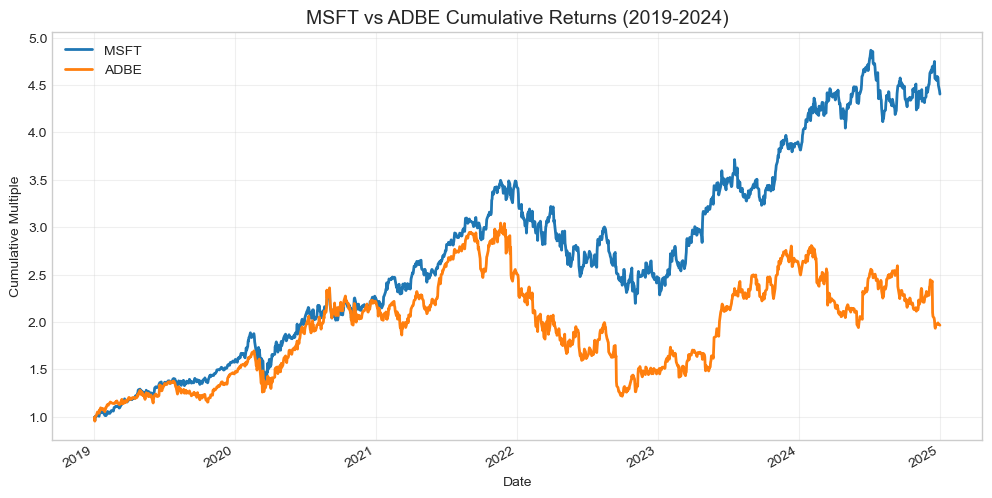

In [40]:
plt.figure(figsize=(12,6))
(1 + stocks).cumprod().plot(linewidth=2, ax=plt.gca())
plt.title('MSFT vs ADBE Cumulative Returns (2019-2024)', fontsize=14)
plt.ylabel('Cumulative Multiple')
plt.xlabel('Date')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

7.2 Annual Return & Volatility 

<Figure size 1000x500 with 0 Axes>

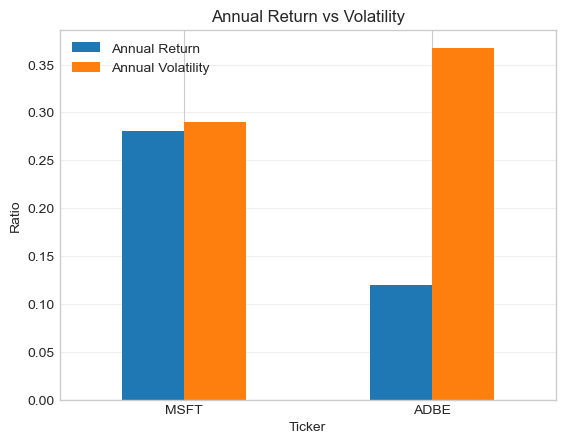

In [41]:
plt.figure(figsize=(10,5))
metrics_df.set_index('Ticker')[['Annual Return','Annual Volatility']].plot(kind='bar')
plt.title('Annual Return vs Volatility')
plt.ylabel('Ratio')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

7.3 Maximum Drawdown

<Figure size 700x500 with 0 Axes>

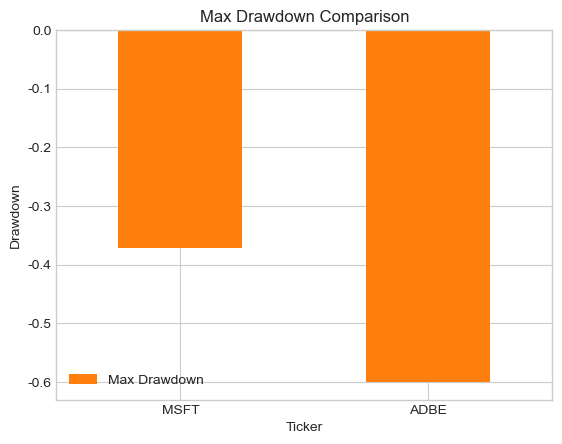

In [42]:
plt.figure(figsize=(7,5))
metrics_df.plot(x='Ticker', y='Max Drawdown', kind='bar', color="#ff7f0e")
plt.title('Max Drawdown Comparison')
plt.ylabel('Drawdown')
plt.xticks(rotation=0)
plt.show()

7.4 Sharpe Ratio 

<Figure size 700x500 with 0 Axes>

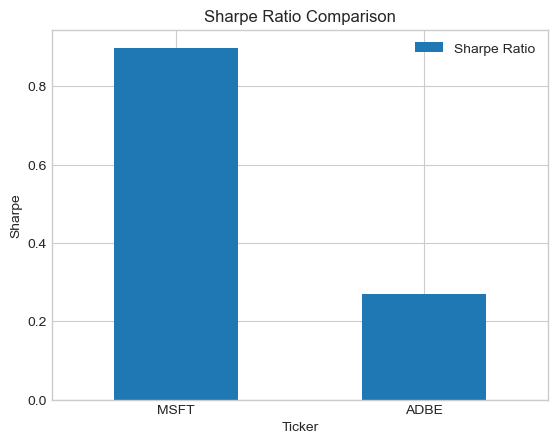

In [43]:
plt.figure(figsize=(7,5))
metrics_df.plot(x='Ticker', y='Sharpe Ratio', kind='bar', color="#1f77b4")
plt.title('Sharpe Ratio Comparison')
plt.ylabel('Sharpe')
plt.xticks(rotation=0)
plt.show()

7.5 Beta Coefficient 

<Figure size 700x500 with 0 Axes>

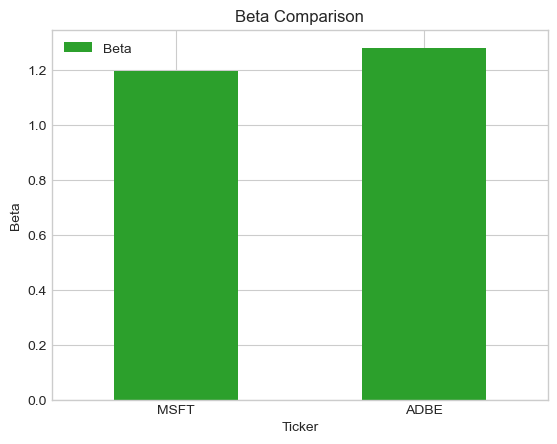

In [44]:
plt.figure(figsize=(7,5))
metrics_df.plot(x='Ticker', y='Beta', kind='bar', color="#2ca02c")
plt.title('Beta Comparison')
plt.ylabel('Beta')
plt.xticks(rotation=0)
plt.show()

7.6 Correlation Heatmap

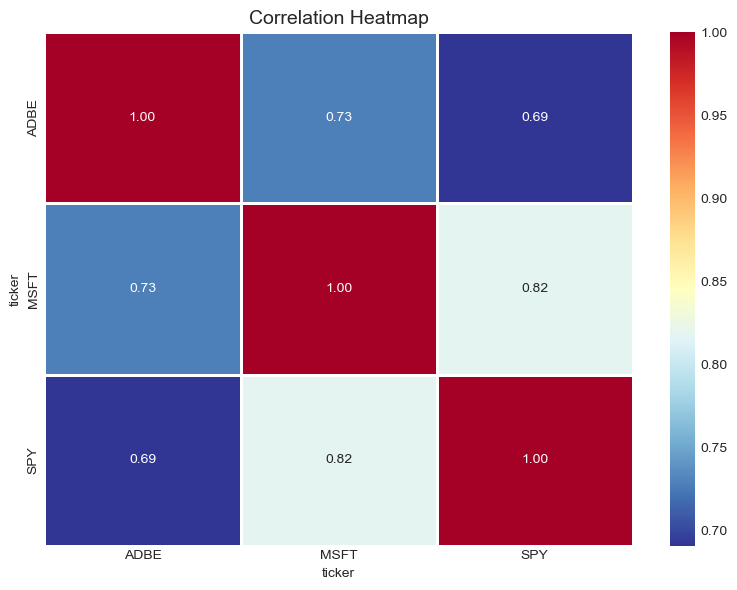

In [45]:
plt.figure(figsize=(8, 6))
corr_matrix = ret_pivot.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', linewidths=1, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


## 8. Final Dataset  & Export

In [46]:
final_dataset = ret_pivot.copy()
final_dataset.columns = ['MSFT Return', 'ADBE Return', 'SPX Return']
final_dataset.index.name = 'Date'

print("===== Final Clean Daily Return Dataset =====")
print(final_dataset.head())

# Export to CSV
final_dataset.to_csv("MSFT_ADBE_Investment_Analysis_Dataset.csv", index=True)
print("\n✅ Dataset exported successfully!")

===== Final Clean Daily Return Dataset =====
            MSFT Return  ADBE Return  SPX Return
Date                                            
2019-01-02    -0.007382     -0.00443     0.00104
2019-01-03    -0.039498    -0.036788   -0.023863
2019-01-04     0.048632     0.046509    0.033496
2019-01-07     0.013573     0.001275    0.007885
2019-01-08     0.014918     0.007251    0.009395

✅ Dataset exported successfully!
